In [10]:

# CIFAR-10 Image Classifier - Complete Code
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time


In [11]:
# 1. CONFIGURATION

class Config:
    # Data
    BATCH_SIZE = 64
    NUM_WORKERS = 2
    
    # Model
    NUM_CLASSES = 10
    
    # Training
    LEARNING_RATE = 0.001
    NUM_EPOCHS = 10
    
    # Paths
    DATA_ROOT = './data'
    MODEL_PATH = 'cifar10_best_model.pth'
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [12]:
# 2. DATA LOADING

def get_data():
    """Load CIFAR-10 dataset"""
    
    # Transformations
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2023, 0.1994, 0.2010]
    
    train_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
    
    # Load datasets
    train_dataset = torchvision.datasets.CIFAR10(
        root=Config.DATA_ROOT,
        train=True,
        download=True,
        transform=train_transform
    )
    
    test_dataset = torchvision.datasets.CIFAR10(
        root=Config.DATA_ROOT,
        train=False,
        download=True,
        transform=test_transform
    )
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=True,
        num_workers=Config.NUM_WORKERS,
        pin_memory=True
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=Config.BATCH_SIZE,
        shuffle=False,
        num_workers=Config.NUM_WORKERS,
        pin_memory=True
    )
    
    classes = train_dataset.classes
    
    return train_loader, test_loader, classes

In [13]:
# 3. MODEL ARCHITECTURE

class CIFAR10CNN(nn.Module):
    """CNN for CIFAR-10 classification"""
    
    def __init__(self):
        super().__init__()
        
        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)
        
        # Regularization
        self.dropout = nn.Dropout(0.5)
        
        # Activation
        self.relu = nn.ReLU()
    
    def forward(self, x):
        # Conv blocks
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        
        # Flatten
        x = x.view(-1, 128 * 4 * 4)
        
        # Fully connected layers
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

In [14]:
# 4. TRAINING FUNCTIONS

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
        
        if batch_idx % 100 == 99:
            print(f"  Batch {batch_idx+1}: Loss: {running_loss/100:.4f}, Acc: {100*correct/total:.2f}%")
            running_loss = 0.0
    
    return 100 * correct / total

def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    
    return val_loss / len(val_loader), 100 * correct / total

def train_full(model, train_loader, test_loader, config):
    """Complete training pipeline"""
    
    print("=" * 60)
    print("CIFAR-10 TRAINING")
    print(f"Device: {config.DEVICE}")
    print(f"Batch Size: {config.BATCH_SIZE}")
    print(f"Learning Rate: {config.LEARNING_RATE}")
    print(f"Epochs: {config.NUM_EPOCHS}")
    print("=" * 60)
    
    # Setup
    model = model.to(config.DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    
    # Training history
    history = {'train_acc': [], 'val_acc': [], 'val_loss': []}
    best_acc = 0.0
    
    start_time = time.time()
    
    for epoch in range(1, config.NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{config.NUM_EPOCHS}")
        print("-" * 40)
        
        # Train
        train_acc = train_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
        
        # Validate
        val_loss, val_acc = validate(model, test_loader, criterion, config.DEVICE)
        
        # Save history
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)
        
        # Print results
        print(f"Train Acc: {train_acc:.2f}%")
        print(f"Val Acc: {val_acc:.2f}%, Val Loss: {val_loss:.4f}")
        
        # Save best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), config.MODEL_PATH)
            print(f"✓ Best model saved! (Acc: {best_acc:.2f}%)")
    
    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time/60:.2f} minutes")
    print(f"Best Validation Accuracy: {best_acc:.2f}%")
    
    return model, history

In [7]:
# 5. EVALUATION FUNCTIONS

def evaluate_model(model, test_loader, classes, device):
    """Detailed evaluation"""
    model.eval()
    class_correct = {c: 0 for c in range(len(classes))}
    class_total = {c: 0 for c in range(len(classes))}
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
            for target, pred in zip(targets, predicted):
                if target == pred:
                    class_correct[target.item()] += 1
                class_total[target.item()] += 1
    
    # Overall accuracy
    overall_acc = 100 * np.sum(np.array(all_preds) == np.array(all_targets)) / len(all_targets)
    
    print("\n" + "=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)
    print(f"Overall Accuracy: {overall_acc:.2f}%\n")
    
    print("Per-Class Accuracy:")
    for i in range(len(classes)):
        if class_total[i] > 0:
            acc = 100 * class_correct[i] / class_total[i]
            print(f"  {classes[i]:15s}: {acc:.2f}%")
    
    return overall_acc, all_preds, all_targets


In [15]:
# 6. VISUALIZATION

def plot_results(history):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history['train_acc'], label='Train', linewidth=2)
    axes[0].plot(history['val_acc'], label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].set_title('Training and Validation Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    axes[1].plot(history['val_loss'], label='Validation Loss', linewidth=2, color='red')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.savefig('training_results.png', dpi=300)
    plt.show()

def show_predictions(model, test_loader, classes, device, num_images=12):
    """Show sample predictions"""
    model.eval()
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    
    images_gpu = images[:num_images].to(device)
    with torch.no_grad():
        outputs = model(images_gpu)
        _, predicted = outputs.max(1)
    
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()
    
    for idx in range(num_images):
        img = images[idx].cpu().numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        
        axes[idx].imshow(img)
        axes[idx].set_title(
            f"True: {classes[labels[idx]]}\nPred: {classes[predicted[idx]]}",
            color='green' if predicted[idx] == labels[idx] else 'red'
        )
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=300)
    plt.show()


WEEK 1: CIFAR-10 IMAGE CLASSIFIER
Tech Prime Pvt Limited - Advanced AI/ML Internship

Loading CIFAR-10 dataset...
Training samples: 50000
Test samples: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Creating model...
Model parameters: 620,810

Starting training...
CIFAR-10 TRAINING
Device: cuda
Batch Size: 64
Learning Rate: 0.001
Epochs: 10

Epoch 1/10
----------------------------------------
  Batch 100: Loss: 1.9750, Acc: 27.22%
  Batch 200: Loss: 1.6346, Acc: 33.24%
  Batch 300: Loss: 1.5558, Acc: 36.10%
  Batch 400: Loss: 1.4548, Acc: 38.71%
  Batch 500: Loss: 1.4221, Acc: 40.49%
  Batch 600: Loss: 1.3873, Acc: 41.99%
  Batch 700: Loss: 1.3108, Acc: 43.58%
Train Acc: 44.48%
Val Acc: 57.38%, Val Loss: 1.1913
✓ Best model saved! (Acc: 57.38%)

Epoch 2/10
----------------------------------------
  Batch 100: Loss: 1.2507, Acc: 54.53%
  Batch 200: Loss: 1.2256, Acc: 55.53%
  Batch 300: Loss: 1.2151, Acc: 55.89%
  Batch 400: Lo

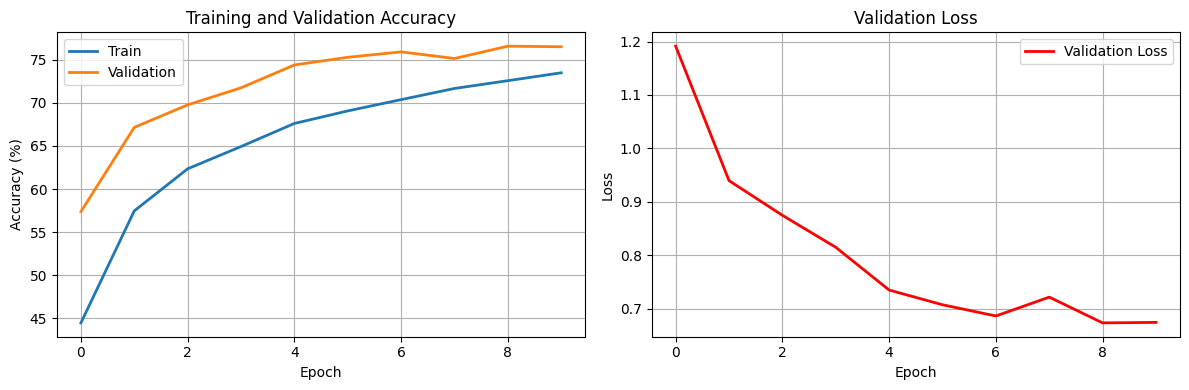

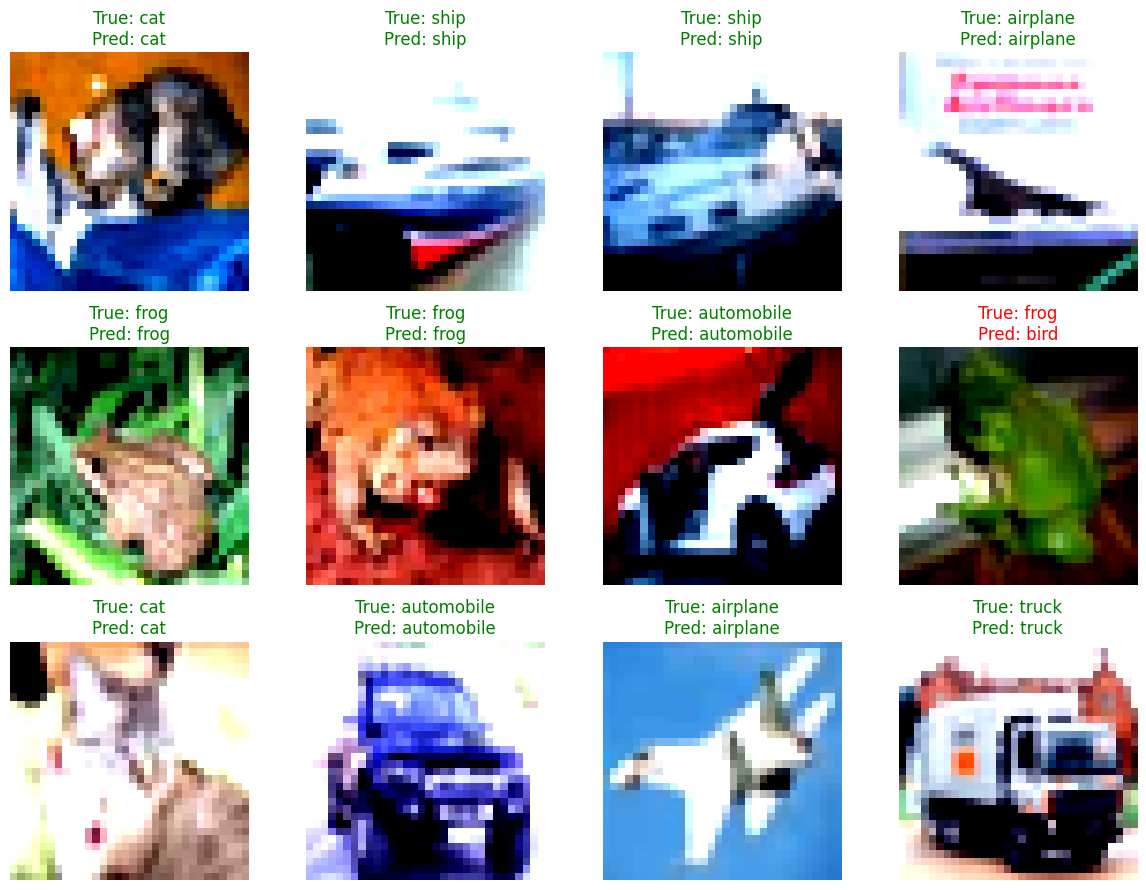


✓ PROJECT COMPLETED SUCCESSFULLY!

Files saved:
  - cifar10_best_model.pth
  - training_results.png
  - predictions.png


In [16]:
# 7. MAIN

def main():
    print("=" * 60)
    print("WEEK 1: CIFAR-10 IMAGE CLASSIFIER")
    print("Tech Prime Pvt Limited - Advanced AI/ML Internship")
    print("=" * 60)
    
    # Load data
    print("\nLoading CIFAR-10 dataset...")
    train_loader, test_loader, classes = get_data()
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Test samples: {len(test_loader.dataset)}")
    print(f"Classes: {classes}")
    
    # Create model
    print("\nCreating model...")
    model = CIFAR10CNN()
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,}")
    
    # Train
    print("\nStarting training...")
    model, history = train_full(model, train_loader, test_loader, Config)
    
    # Load best model
    print("\nLoading best model...")
    model.load_state_dict(torch.load(Config.MODEL_PATH))
    
    # Evaluate
    print("\nEvaluating...")
    evaluate_model(model, test_loader, classes, Config.DEVICE)
    
    # Visualize
    print("\nGenerating plots...")
    plot_results(history)
    show_predictions(model, test_loader, classes, Config.DEVICE)
    
    print("\n" + "=" * 60)
    print("✓ PROJECT COMPLETED SUCCESSFULLY!")
    print("=" * 60)
    print("\nFiles saved:")
    print(f"  - {Config.MODEL_PATH}")
    print("  - training_results.png")
    print("  - predictions.png")

if __name__ == "__main__":
    main()